In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import scanpy as sc
import matplotlib.pyplot as plt
import functools
import pandas as pd
import ot as pot
import warnings
import os

from sc_flow import SCFlow
from sc_flow.backends.torch.coupling import ot_linear_coupling
from sc_flow.data.samplers._train import MultiTransitionSampler
from sc_flow.backends.torch.metrics import EnergyDistance, MaximumMeanDiscrepancy
from sc_flow.backends.torch.probability_paths import LinearGaussianProbabilityPath
from sc_flow.backends.torch.coupling._coupling import configure_ot_debug
from sc_flow.backends.torch.coupling._coupling import _OT_DEBUG

SEED = 44
np.random.seed(SEED)
torch.manual_seed(SEED)
prng = torch.Generator().manual_seed(SEED)
warnings.filterwarnings("ignore")

In [3]:
DATA_PATH = "400_data\\GSE232025_stereoseq_n256.h5ad"
STAGES_ALL = ["Stage44", "Stage54", "Stage57", "Juvenile", "Adult"]
STAGE_TIMES = {"Stage44": 0, "Stage54": 1, "Stage57": 2, "Juvenile": 3, "Adult": 4}
MATCHED_KEYS = {
    ("Stage44",): ("Stage54",),
    ("Stage54",): ("Stage57",),
    ("Stage57",): ("Juvenile",),
}
PRED_KEYS = {
    ("Stage44", "Stage54"),
    ("Stage54", "Stage57"),
    ("Stage57", "Juvenile"),
    ("Juvenile", "Adult"),
}
T_START_PRED = [0, 1, 2, 3]
T_END_PRED = [1, 2, 3, 4]

In [4]:
ALPHA = 0.5
LAMBDA = 0.4
hidden_dims = (10, 10, 10)
activation = torch.nn.SELU
epoch = 10
lr = 1e-4
batch_size = 256
probability_path = LinearGaussianProbabilityPath(sigma=0.9, prng=prng)
scale_method = 1.0  # Cost matrix is not scaled in ContextFlow
reg = 0.1
debug_folder = "debug001"
time_sampler = lambda shape, device=None, dtype=None: torch.linspace(0.01, 0.99, shape[0], device=device, dtype=dtype)
N_EVAL = 1500

In [5]:
adata = sc.read_h5ad(DATA_PATH)

X_pca = adata.obsm["X_pca"].astype(np.float32)
ss_context = adata.obsm["local_mean_X_pca"].astype(np.float32)
lr_pattern = adata.obsm["LR_pattern"].astype(np.float32)

adata.uns["stage_emb"] = {s: np.array([t], dtype=np.float32) for s, t in STAGE_TIMES.items()}
adata.obs["day"] = adata.obs["day"].astype(int).map(dict(enumerate(STAGES_ALL)))
adata.obsm["X_state_ctx"] = np.concatenate([X_pca, ss_context, lr_pattern], axis=1)

configure_ot_debug(output_dir=debug_folder, max_steps=10)

In [6]:
def ctf_c_coupling(source_lin, target_lin, CTF_LAMBDA, CTF_ALPHA, N_PCA, N_SS, scale_method, reg, **kwargs):
    """CTF-C: ot_linear_coupling with spatially-biased cost (SS + LR TPM)."""
    src_pca = source_lin[:, :N_PCA]
    src_ss = source_lin[:, N_PCA : N_PCA + N_SS]
    src_lr = source_lin[:, N_PCA + N_SS :]

    tgt_pca = target_lin[:, :N_PCA]
    tgt_ss = target_lin[:, N_PCA : N_PCA + N_SS]
    tgt_lr = target_lin[:, N_PCA + N_SS :]

    cost_components = {}

    def cost_fn(src, tgt):
        """Build spatially-blended OT cost from PCA, SS, and LR distances."""
        C_pca = torch.cdist(src, tgt) ** 2
        C_pca = C_pca / C_pca.max()

        SS = torch.cdist(src_ss, tgt_ss) ** 2
        SS = SS / SS.max()

        LR = torch.cdist(src_lr, tgt_lr) ** 2
        LR = LR / LR.max()

        M = CTF_ALPHA * SS + (1 - CTF_ALPHA) * LR
        cost = CTF_LAMBDA * C_pca + (1 - CTF_LAMBDA) * M

        cost_components["C_pca"] = C_pca
        cost_components["SS"] = SS
        cost_components["LR"] = LR
        cost_components["M"] = M
        cost_components["cost"] = cost
        return cost

    result = ot_linear_coupling(src_pca, tgt_pca, cost_fn=cost_fn, scale_cost=scale_method, reg=reg)

    if _OT_DEBUG["enabled"] and _OT_DEBUG["_step"] <= _OT_DEBUG["max_steps"]:
        step_dir = os.path.join(_OT_DEBUG["output_dir"], f"step_{_OT_DEBUG['_step']:04d}")
        np.savez_compressed(
            os.path.join(step_dir, f"transition_{_OT_DEBUG['_transition']}_cost_inputs.npz"),
            src_ss=src_ss.detach().cpu().numpy(),
            src_lr=src_lr.detach().cpu().numpy(),
            tgt_ss=tgt_ss.detach().cpu().numpy(),
            tgt_lr=tgt_lr.detach().cpu().numpy(),
            **{k: v.detach().cpu().numpy() for k, v in cost_components.items()},
        )

    return result

In [ ]:
# def compute_w2(X, Y):
#    """Compute 2-Wasserstein distance between X and Y."""
# rng = np.random.RandomState(SEED)
# Xi = X[rng.choice(X.shape[0], min(N_EVAL, X.shape[0]), replace=False)].astype(np.float64)
# Yi = Y[rng.choice(Y.shape[0], min(N_EVAL, Y.shape[0]), replace=False)].astype(np.float64)
# a, b = pot.unif(Xi.shape[0]), pot.unif(Yi.shape[0])
# M = torch.cdist(torch.tensor(Xi).float(), torch.tensor(Yi).float()).numpy().astype(np.float64) ** 2
# return float(np.sqrt(pot.emd2(a, b, M)))
def compute_w2(X, Y):
    """Compute sliced 2-Wasserstein distance between X and Y."""
    rng = np.random.RandomState(SEED)
    Xi = X[rng.choice(X.shape[0], min(N_EVAL, X.shape[0]), replace=False)].astype(np.float64)
    Yi = Y[rng.choice(Y.shape[0], min(N_EVAL, Y.shape[0]), replace=False)].astype(np.float64)
    return float(pot.sliced.sliced_wasserstein_distance(Xi, Yi, n_projections=200, p=2, seed=SEED))


def compute_mmd(X, Y):
    """Compute MMD between X and Y."""
    rng = np.random.RandomState(SEED)
    Xi = torch.tensor(X[rng.choice(X.shape[0], min(N_EVAL, X.shape[0]), replace=False)]).float()
    Yi = torch.tensor(Y[rng.choice(Y.shape[0], min(N_EVAL, Y.shape[0]), replace=False)]).float()
    m = MaximumMeanDiscrepancy()
    m.update(Xi, Yi)
    return float(m.compute())


def compute_energy(X, Y):
    """Compute energy distance between X and Y."""
    rng = np.random.RandomState(SEED)
    Xi = torch.tensor(X[rng.choice(X.shape[0], min(N_EVAL, X.shape[0]), replace=False)]).float()
    Yi = torch.tensor(Y[rng.choice(Y.shape[0], min(N_EVAL, Y.shape[0]), replace=False)]).float()
    m = EnergyDistance()
    m.update(Xi, Yi)
    return float(m.compute())

In [8]:
class FixedMultiTransitionSampler(MultiTransitionSampler):
    """MultiTransitionSampler that always uses all cells in their natural order.

    Overrides _sample_indices to return np.arange(n_obs) instead of a random
    permutation, so row i of the coupling matrix always corresponds to cell i
    in the dataset â€” making the coupling fully comparable across epochs.
    """

    def _sample_indices(self, n_obs, batch_size=None):
        return np.arange(n_obs)

In [9]:
SCFlow.register_adata(
    adata,
    sample_rep="X_pca",
    coupling_rep="X_state_ctx",
    conditions={"day": ["day"]},
    conditions_reps={"day": "stage_emb"},
    matched_keys=MATCHED_KEYS,
)

ctf_c_partial = functools.partial(
    ctf_c_coupling,
    CTF_LAMBDA=LAMBDA,
    CTF_ALPHA=ALPHA,
    N_PCA=50,
    N_SS=50,
    scale_method=scale_method,
    reg=reg,
)

model = SCFlow(
    method_id="cfm",
    backend="torch",
    match_fn=ctf_c_partial,
    vf_decoder_mlp_kwargs={"hidden_dims": hidden_dims, "activation_cls": activation},
    time_sampler=time_sampler,
)

model.train(
    adata,
    callbacks=None,
    sort=True,
    n_train_steps=epoch,
    train_batch_size=batch_size,
    train_sampler=FixedMultiTransitionSampler,
    optim_kwargs={"lr": lr},
    timepoints=[0, 1, 2, 3],
    probability_path=probability_path,
)

preds_extra = {}
for (src, tgt), ts, te in zip(PRED_KEYS, T_START_PRED, T_END_PRED, strict=False):
    result = model.predict(
        adata,
        sort=True,
        matched_keys={(src,): (tgt,)},
        return_trajectory=True,
        num_steps=400,
        t_start=ts,
        t_end=te,
    )
    preds_extra[(src, tgt)] = np.array(result.X)

Predicting: 100%|██████████| 1/1 [00:00<00:00,  2.40it/s]


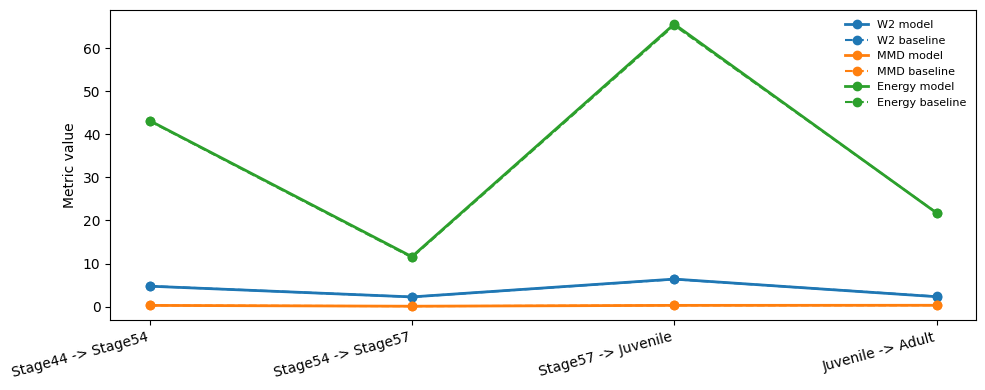

In [68]:
rows = []
ordered_keys = sorted(preds_extra.keys(), key=lambda x: STAGES_ALL.index(x[0]))
for src, tgt in ordered_keys:
    pred = preds_extra[(src, tgt)]
    true_tgt = adata[adata.obs["day"] == tgt].obsm["X_pca"].astype(np.float32)
    src_cells = adata[adata.obs["day"] == src].obsm["X_pca"].astype(np.float32)

    rows.append(
        {
            "transition": f"{src} -> {tgt}",
            "W2 (model)": compute_w2(pred, true_tgt),
            "W2 (baseline)": compute_w2(src_cells, true_tgt),
            "MMD (model)": compute_mmd(pred, true_tgt),
            "MMD (baseline)": compute_mmd(src_cells, true_tgt),
            "Energy (model)": compute_energy(pred, true_tgt),
            "Energy (baseline)": compute_energy(src_cells, true_tgt),
        }
    )

df = pd.DataFrame(rows).set_index("transition").round(4)

metrics = [("W2", "#1f77b4"), ("MMD", "#ff7f0e"), ("Energy", "#2ca02c")]
x = np.arange(len(df))
x_labels = df.index.tolist()

fig, ax = plt.subplots(figsize=(10, 4))
for name, color in metrics:
    ax.plot(x, df[f"{name} (model)"].values, color=color, linestyle="-", linewidth=2, marker="o", label=f"{name} model")
    ax.plot(
        x,
        df[f"{name} (baseline)"].values,
        color=color,
        linestyle="--",
        linewidth=1.5,
        marker="o",
        label=f"{name} baseline",
    )
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=15, ha="right")
ax.set_ylabel("Metric value")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# Temp Results

In [26]:
debug_folder = "debug001"

In [34]:
trans_cost0 = np.load(
    rf"C:\Users\HP\Documents\munich_work\sc-flow-tools\docs\notebooks\examples\tutorials\{debug_folder}\step_0001\transition_0_cost_inputs.npz"
)
trans_cost1 = np.load(
    rf"C:\Users\HP\Documents\munich_work\sc-flow-tools\docs\notebooks\examples\tutorials\{debug_folder}\step_0002\transition_0_cost_inputs.npz"
)

trans0 = np.load(
    rf"C:\Users\HP\Documents\munich_work\sc-flow-tools\docs\notebooks\examples\tutorials\{debug_folder}\step_0001\transition_0.npz"
)
trans1 = np.load(
    rf"C:\Users\HP\Documents\munich_work\sc-flow-tools\docs\notebooks\examples\tutorials\{debug_folder}\step_0002\transition_0.npz"
)

trans_prob0 = np.load(
    rf"C:\Users\HP\Documents\munich_work\sc-flow-tools\docs\notebooks\examples\tutorials\{debug_folder}\step_0001\transition_0_prob_path.npz"
)
trans_prob1 = np.load(
    rf"C:\Users\HP\Documents\munich_work\sc-flow-tools\docs\notebooks\examples\tutorials\{debug_folder}\step_0002\transition_0_prob_path.npz"
)

In [35]:
for key in ["src_ss", "src_lr", "tgt_ss", "tgt_lr", "C_pca", "SS", "LR", "M", "cost"]:
    print(f"{key} equal: {np.array_equal(trans_cost0[key], trans_cost1[key])}")
print("")
for key in ["source_lin", "target_lin", "dist_pre", "dist_post", "coupling_matrix", "source_idxs", "target_idxs"]:
    print(f"{key} equal: {np.array_equal(trans0[key], trans1[key])}")
print("")
for key in ["t", "xt", "ut", "latent", "vt", "cond_day"]:
    print(f"{key} equal: {np.array_equal(trans_prob0[key], trans_prob1[key])}")

src_ss equal: True
src_lr equal: True
tgt_ss equal: True
tgt_lr equal: True
C_pca equal: True
SS equal: True
LR equal: True
M equal: True
cost equal: True

source_lin equal: True
target_lin equal: True
dist_pre equal: True
dist_post equal: True
coupling_matrix equal: True
source_idxs equal: False
target_idxs equal: False

t equal: True
xt equal: False
ut equal: False
latent equal: False
vt equal: False
cond_day equal: True


In [49]:
path_loc = r"C:\Users\HP\Documents\munich_work\sc-flow-tools\docs\notebooks\examples\tutorials\Testing\step_artifacts\02_epochs"
b0 = np.load(path_loc + r"\epoch_000\transition_0\batch\b0.npy")
b1 = np.load(path_loc + r"\epoch_000\transition_0\batch\b1.npy")
ct0 = np.load(path_loc + r"\epoch_000\transition_0\batch\ct0.npy")
ct1 = np.load(path_loc + r"\epoch_000\transition_0\batch\ct1.npy")
lr0 = np.load(path_loc + r"\epoch_000\transition_0\batch\lr0.npy")
lr1 = np.load(path_loc + r"\epoch_000\transition_0\batch\lr1.npy")
mc0 = np.load(path_loc + r"\epoch_000\transition_0\batch\mc0.npy")
mc1 = np.load(path_loc + r"\epoch_000\transition_0\batch\mc1.npy")
x0 = np.load(path_loc + r"\epoch_000\transition_0\batch\x0.npy")
x1 = np.load(path_loc + r"\epoch_000\transition_0\batch\x1.npy")

gd_norm = np.load(path_loc + r"\epoch_000\transition_0\ot\gene_dist_normalized.npy")
lr_norm = np.load(path_loc + r"\epoch_000\transition_0\ot\lr_dist_normalized.npy")
mc_norm = np.load(path_loc + r"\epoch_000\transition_0\ot\mc_dist_normalized.npy")
M = np.load(path_loc + r"\epoch_000\transition_0\ot\M.npy")
ot_raw = np.load(path_loc + r"\epoch_000\transition_0\ot\ot_plan.npy")
ot_norm = np.load(path_loc + r"\epoch_000\transition_0\ot\ot_plan_normalized.npy")

In [39]:
path_loc = r"C:\Users\HP\Documents\munich_work\sc-flow-tools\docs\notebooks\examples\tutorials\Testing\step_artifacts\02_epochs"
b0_1 = np.load(path_loc + r"\epoch_001\transition_0\batch\b0.npy")
b1_1 = np.load(path_loc + r"\epoch_001\transition_0\batch\b1.npy")
ct0_1 = np.load(path_loc + r"\epoch_001\transition_0\batch\ct0.npy")
ct1_1 = np.load(path_loc + r"\epoch_001\transition_0\batch\ct1.npy")
lr0_1 = np.load(path_loc + r"\epoch_001\transition_0\batch\lr0.npy")
lr1_1 = np.load(path_loc + r"\epoch_001\transition_0\batch\lr1.npy")
mc0_1 = np.load(path_loc + r"\epoch_001\transition_0\batch\mc0.npy")
mc1_1 = np.load(path_loc + r"\epoch_001\transition_0\batch\mc1.npy")
x0_1 = np.load(path_loc + r"\epoch_001\transition_0\batch\x0.npy")
x1_1 = np.load(path_loc + r"\epoch_001\transition_0\batch\x1.npy")

gd_norm1 = np.load(path_loc + r"\epoch_001\transition_0\ot\gene_dist_normalized.npy")
lr_norm1 = np.load(path_loc + r"\epoch_001\transition_0\ot\lr_dist_normalized.npy")
mc_norm1 = np.load(path_loc + r"\epoch_001\transition_0\ot\mc_dist_normalized.npy")
M1 = np.load(path_loc + r"\epoch_001\transition_0\ot\M.npy")
ot_raw1 = np.load(path_loc + r"\epoch_001\transition_0\ot\ot_plan.npy")
ot_norm1 = np.load(path_loc + r"\epoch_001\transition_0\ot\ot_plan_normalized.npy")

In [40]:
pairs = [
    ("b0", "b0_1"),
    ("b1", "b1_1"),
    ("ct0", "ct0_1"),
    ("ct1", "ct1_1"),
    ("lr0", "lr0_1"),
    ("lr1", "lr1_1"),
    ("mc0", "mc0_1"),
    ("mc1", "mc1_1"),
    ("x0", "x0_1"),
    ("x1", "x1_1"),
    ("gd_norm", "gd_norm1"),
    ("lr_norm", "lr_norm1"),
    ("mc_norm", "mc_norm1"),
    ("M", "M1"),
    ("ot_raw", "ot_raw1"),
    ("ot_norm", "ot_norm1"),
]

for a, b in pairs:
    if a in globals() and b in globals():
        print(f"{a} vs {b}: {np.array_equal(globals()[a], globals()[b])}")

b0 vs b0_1: True
b1 vs b1_1: True
ct0 vs ct0_1: True
ct1 vs ct1_1: True
lr0 vs lr0_1: True
lr1 vs lr1_1: True
mc0 vs mc0_1: True
mc1 vs mc1_1: True
x0 vs x0_1: True
x1 vs x1_1: True


In [ ]:
print(np.array_equal(trans_cost0["src_ss"], mc0))
print(np.array_equal(trans_cost0["tgt_ss"], mc1))
print(np.array_equal(trans_cost0["src_lr"], lr0))
print(np.array_equal(trans_cost0["tgt_lr"], lr1))
print(np.allclose(trans_cost0["SS"], mc_norm, rtol=1e-5, atol=1e-8))
print(np.allclose(trans_cost0["LR"], lr_norm, rtol=1e-5, atol=1e-8))
print(np.allclose(trans_cost0["C_pca"], gd_norm, rtol=1e-5, atol=1e-8))
print(np.allclose(trans_cost0["cost"], M, rtol=1e-5, atol=1e-8))

print(np.allclose(trans0["coupling_matrix"], ot_raw, rtol=1e-5, atol=1e-8))

True
True
True
True
True
True
True
True


In [ ]:
# Time encoder is default True. Check